In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import matplotlib.gridspec as gridspec

from itertools import combinations
from statannotations.Annotator import Annotator
from statannotations.stats.StatTest import StatTest
from datetime import datetime
from zoneinfo import ZoneInfo
from tqdm import tqdm

from ar_model_utils import apply_sliding_window
from plot_utils import *

import warnings
warnings.filterwarnings('ignore')

plt.rcParams["svg.fonttype"] = "none"
mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = ['Arial']

%load_ext autoreload
%autoreload 2

In [2]:
TZ = ZoneInfo('America/Chicago')
COL_PAL = {'Pre-DBS': '#ffe900', 'Disinhibited': '#ff0000', 'Non-Responder': '#ffb900', 'Responder': '#0000ff', 'Partial Responder': "#21cfff", 'Unknown': "#000000",  'Transition': '#808080', 'Relapse': "#f58012"}
PARTIAL_RESPONDERS = ['B006', 'B008', 'B017', 'B019']

In [3]:
df = pd.read_parquet('df_for_paper_processed.parq')
df.head(5)

,pt_id,time_bin_time,days_since_dbs,lfp_left_raw,stim_left,lfp_right_raw,stim_right,lead_location,left_lead_model,right_lead_model,...,left_R2_rolling_avg_14d,left_R2_rolling_avg_21d,left_R2_rolling_avg_28d,left_delta_R2_rolling_avg_1d,left_delta_R2_rolling_avg_3d,left_delta_R2_rolling_avg_5d,left_delta_R2_rolling_avg_7d,left_delta_R2_rolling_avg_14d,left_delta_R2_rolling_avg_21d,left_delta_R2_rolling_avg_28d
0,AA001,00:00:00,-8,253.0,0.0,366.0,0.0,VC/VS,LEAD_B33015,LEAD_B33015,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,AA001,00:10:00,-8,181.0,0.0,312.0,0.0,VC/VS,LEAD_B33015,LEAD_B33015,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,AA001,00:20:00,-8,198.0,0.0,306.0,0.0,VC/VS,LEAD_B33015,LEAD_B33015,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,AA001,00:30:00,-8,185.0,0.0,269.0,0.0,VC/VS,LEAD_B33015,LEAD_B33015,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,AA001,00:40:00,-8,215.0,0.0,314.0,0.0,VC/VS,LEAD_B33015,LEAD_B33015,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Right Hemisphere R2 Supp Fig

In [6]:
window_size = 3

df.reset_index(drop=True, inplace=True)
hem = 'right'

pt_groups = df.groupby('pt_id', group_keys=False)
ar_features = [f'lfp_{hem}_OvER_interpolate_z_scored_lag_1']
tqdm.pandas(desc=f'Applying autoregressive model for {hem} hem')
hem_results_df = pt_groups.progress_apply(
    lambda g: apply_sliding_window(
        g, ar_features, f'lfp_{hem}_OvER_interpolate_z_scored', window_size=window_size),
    include_groups=False
)
df = df.merge(
    hem_results_df,
    how='left',
    left_index=True,
    right_index=True
)

Applying autoregressive model for right hem: 100%|██████████| 24/24 [00:14<00:00,  1.68it/s]


## A

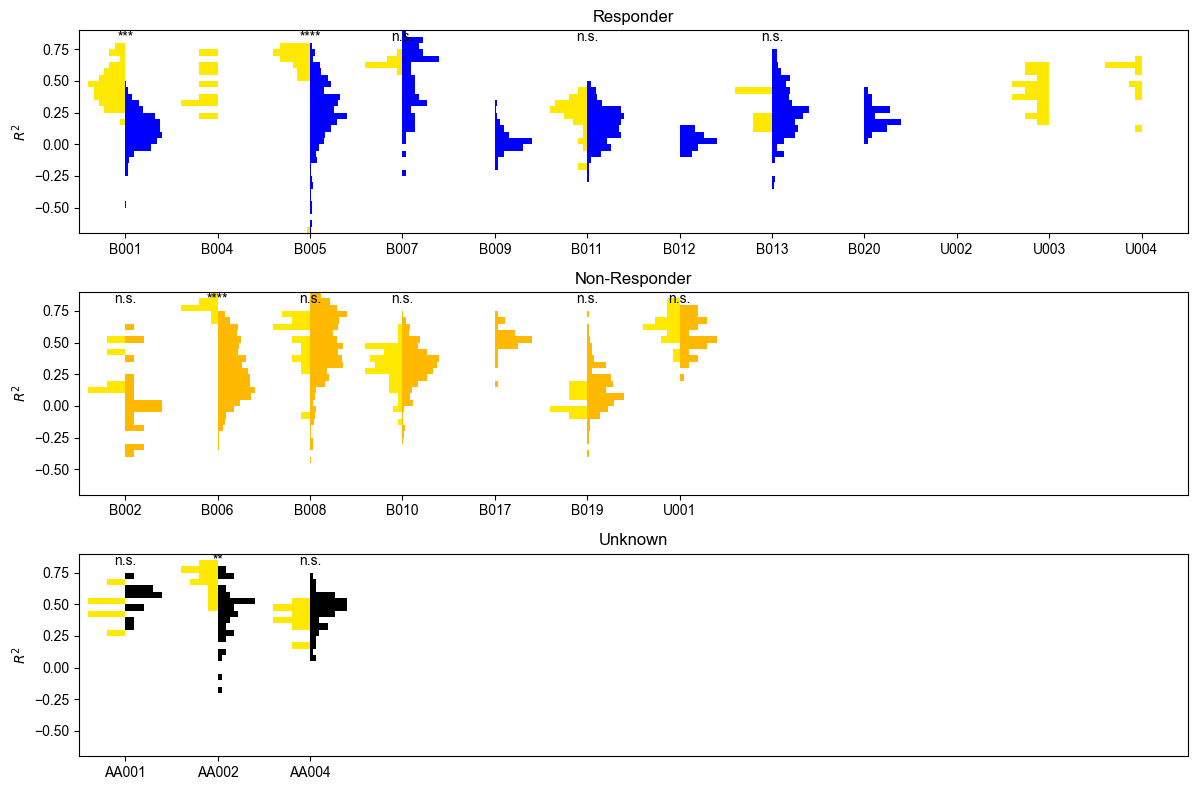

In [7]:
feature = 'lfp_right_OvER_interpolate_R2'
fig, axs = plt.subplots(nrows=3, figsize=(12, 8), sharey=True)
min_val, max_val = df[feature].min(), df[feature].max()
bin_start = np.floor(min_val*10)/10
bin_end = np.ceil(max_val*10)/10
bin_width = 0.05
bins = np.arange(bin_start, bin_end + bin_width, bin_width)

results_dict = {'pt_id': [], 't_stat': [], 'p_val': []}
only_first_14d = False

max_num_pts = 0
df.sort_values(by=['pt_id', 'dummy_timestamp'], inplace=True)
for ax, response_status in zip(axs, ['Responder', 'Non-Responder', 'Unknown']):
    plot_df = df.dropna(subset=feature).query('response_status == @response_status').copy()
    if only_first_14d:
        plot_df = plot_df.query('days_since_dbs <= 14')
    
    max_num_pts = max(max_num_pts, plot_df['pt_id'].nunique())
    for i, (pt_id, pt_df) in enumerate(plot_df.groupby('pt_id')):
        plot_df_daily = pt_df.dropna(subset=[feature]).groupby('days_since_dbs').first().reset_index()
        predbs_days, predbs_vals = plot_df_daily.query('state_label_str == "Pre-DBS"')[['days_since_dbs', feature]].values.T
        stable_state_days, stable_state_vals = plot_df_daily.query('state_label_str == @response_status')[['days_since_dbs', feature]].values.T
        if len(predbs_vals) != 0 and not np.isnan(predbs_vals).all():
            counts_predbs, _ = np.histogram(predbs_vals, bins=bins, density=True)
            counts_predbs /= counts_predbs.max() * 2.5
        else:
            counts_predbs = np.zeros(len(bins)-1)
        if len(stable_state_vals) != 0 and not np.isnan(stable_state_vals).all():
            counts_postdbs, _ = np.histogram(stable_state_vals, bins=bins, density=True)
            counts_postdbs /= counts_postdbs.max() * 2.5
        else:
            counts_postdbs = np.zeros(len(bins)-1)
        ax.barh(bins[:-1], -counts_predbs, height=bin_width, align='edge', left=i,
                color=COL_PAL['Pre-DBS'], edgecolor=None)
        ax.barh(bins[:-1], counts_postdbs, height=bin_width, align='edge', left=i,
                color=COL_PAL[response_status], edgecolor=None)

        # Run a t-test and annotate significance
        if len(predbs_vals) > 1 and len(stable_state_vals) > 1 and not np.isnan(predbs_vals).all() and not np.isnan(stable_state_vals).all():
            t_stat, p_val = ttest_ind_with_neff_correction(predbs_vals, stable_state_vals, predbs_days, stable_state_days)
            ax.text(i, bins[-1], get_asterisk_str(p_val), ha='center', va='top')
        else:
            t_stat, p_val = np.nan, np.nan
        results_dict['pt_id'].append(pt_id)
        results_dict['t_stat'].append(t_stat)
        results_dict['p_val'].append(p_val)
        
    ax.set(title=f'{response_status}',
           xticks=np.arange(plot_df['pt_id'].nunique()),
           xticklabels=plot_df['pt_id'].unique(),)

for ax in axs:
    ax.set(
        xlim=(-0.5, max_num_pts - 0.5),
        ylim=(bin_start, bin_end),
        ylabel=r'$R^2$',
    )

fig.tight_layout()
plt.show()

## B

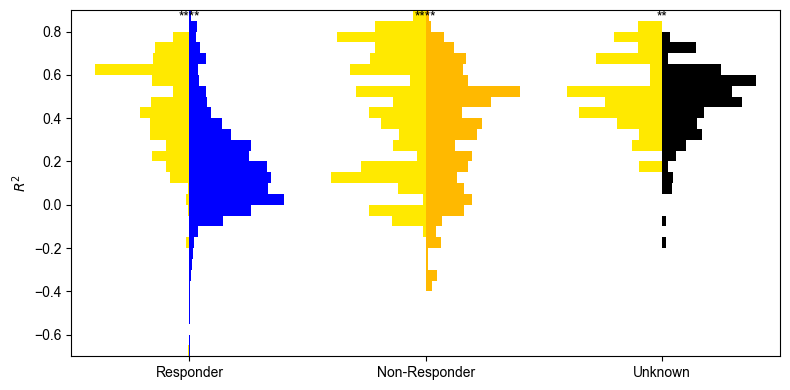

In [8]:
feature = 'lfp_right_OvER_interpolate_R2'
fig, ax = plt.subplots(figsize=(8, 4))
min_val, max_val = df[feature].min(), df[feature].max()
bin_start = np.floor(min_val*10)/10
bin_end = np.ceil(max_val*10)/10
bin_width = 0.05
bins = np.arange(bin_start, bin_end + bin_width, bin_width)

for i, response_status in enumerate(['Responder', 'Non-Responder', 'Unknown']):
    plot_df = df.query('response_status == @response_status')
    plot_df_daily = plot_df.dropna(subset=[feature]).groupby(['pt_id', 'days_since_dbs']).first().reset_index()
    predbs_vals = plot_df_daily.query('state_label_str == "Pre-DBS"')[feature]
    predbs_weights = []
    for pt_id, pt_df in plot_df_daily.groupby('pt_id'):
        num_predbs = pt_df.query('state_label_str == "Pre-DBS"')[feature].shape[0]
        if num_predbs > 0:
            predbs_weights.extend([1/num_predbs] * num_predbs)
    postdbs_vals = plot_df_daily.query('state_label_str == @response_status')[feature]
    postdbs_weights = []
    for pt_id, pt_df in plot_df_daily.groupby('pt_id'):
        num_postdbs = pt_df.query('state_label_str == @response_status')[feature].shape[0]
        if num_postdbs > 0:
            postdbs_weights.extend([1/num_postdbs] * num_postdbs)

    if not predbs_vals.empty and not predbs_vals.isna().all():
        counts_predbs, _ = np.histogram(predbs_vals, bins=bins, density=True, weights=predbs_weights)
        counts_predbs /= counts_predbs.max() * 2.5
    else:
        counts_predbs = np.zeros(len(bins)-1)
    if not postdbs_vals.empty and not postdbs_vals.isna().all():
        counts_postdbs, _ = np.histogram(postdbs_vals, bins=bins, density=True, weights=postdbs_weights)
        counts_postdbs /= counts_postdbs.max() * 2.5
    else:
        counts_postdbs = np.zeros(len(bins)-1)

    ax.barh(bins[:-1], -counts_predbs, height=bin_width, align='edge', left=i,
            color=COL_PAL['Pre-DBS'], edgecolor=None)
    ax.barh(bins[:-1], counts_postdbs, height=bin_width, align='edge', left=i,
            color=COL_PAL[response_status], edgecolor=None)

    # Run a t-test and annotate significance
    if len(predbs_vals) > 1 and len(postdbs_vals) > 1 and not predbs_vals.isna().all() and not postdbs_vals.isna().all():
        t_stat, p_val = stats.ttest_ind(predbs_vals, postdbs_vals, nan_policy='omit')
        predbs_feature_mean = np.mean(predbs_vals) if len(predbs_vals) > 0 and not np.isnan(predbs_vals).all() else np.nan
        postdbs_feature_mean = np.mean(postdbs_vals) if len(postdbs_vals) > 0 and not np.isnan(postdbs_vals).all() else np.nan
        predbs_feature_var = np.var(predbs_vals, ddof=1) if len(predbs_vals) > 1 and not np.isnan(predbs_vals).all() else np.nan
        postdbs_feature_var = np.var(postdbs_vals, ddof=1) if len(postdbs_vals) > 1 and not np.isnan(postdbs_vals).all() else np.nan
        cohens_d = (predbs_feature_mean - postdbs_feature_mean) / (np.sqrt((predbs_feature_var + postdbs_feature_var) / 2)) if not np.isnan(predbs_feature_var) and not np.isnan(postdbs_feature_var) and predbs_feature_var > 0 and postdbs_feature_var > 0 else np.nan
        ax.text(i, bins[-1], get_asterisk_str(p_val), ha='center', va='top')

ax.set(
    xlim=(-0.5, 2.5),
    ylim=(bin_start, bin_end),
    ylabel=r'$R^2$',
    xticks=np.arange(3),
    xticklabels=['Responder', 'Non-Responder', 'Unknown'],
)

fig.tight_layout()
plt.show()

## C

T-test comparing ΔR² between Responders and Non-Responders: t=-0.623, p=5.491e-01


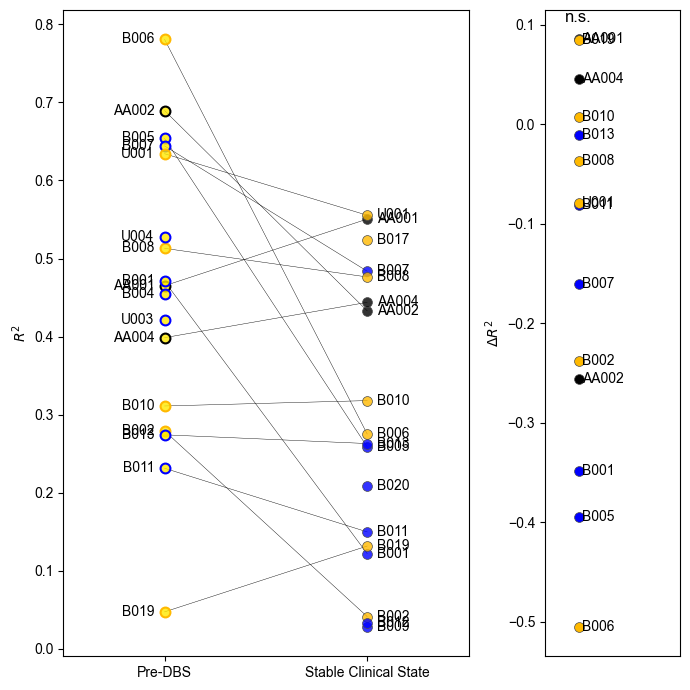

In [9]:
fig, axs = plt.subplots(ncols=2, nrows=1, figsize=(7, 7), width_ratios=[3,1])
side_buffer = 0.5
text_buffer = 0.05
s = 50  # size of the scatter points
alpha = 0.8  # transparency for insides of the scatter points
    
feature = f'lfp_right_OvER_interpolate_R2'
postdbs_query_string = f'(days_since_dbs > 0) and (state_label_str in ["Unknown", "Responder", "Non-Responder"])'
clothesline_df = df.dropna(subset=[feature, 'response_status', 'state_label_str'], how='any').copy()

r_deltas, nr_deltas = [], []
for pt_id, pt_df in clothesline_df.groupby('pt_id'):
    pre_dbs_y = pt_df.query(f'state_label_str == "Pre-DBS"')[feature].mean()
    response_state = pt_df['response_status'].iloc[0]
    post_dbs_y = pt_df.query(postdbs_query_string)[feature].mean()
    delta_y = post_dbs_y - pre_dbs_y
    axs[0].scatter(0, pre_dbs_y, marker='o', color=add_alpha_to_color(COL_PAL['Pre-DBS'], alpha), s=s, edgecolors=COL_PAL[response_state], lw=1.5)
    axs[0].scatter(1, post_dbs_y, marker='o', color=add_alpha_to_color(COL_PAL[response_state], alpha), s=s, edgecolors='#4c4c4c', lw=0.5)
    axs[0].plot([0, 1], [pre_dbs_y, post_dbs_y], c='k', lw=0.3, zorder=0)
    axs[0].text(0-text_buffer, pre_dbs_y, pt_id, ha='right', va='center')
    axs[0].text(1+text_buffer, post_dbs_y, pt_id, ha='left', va='center')

    axs[1].scatter(0, delta_y, marker='o', color=COL_PAL[response_state], s=s, edgecolors='#4c4c4c', lw=0.5)
    axs[1].text(0+text_buffer, delta_y, pt_id, ha='left', va='center')
    if not np.isnan(delta_y):
        match response_state:
            case 'Responder':
                r_deltas.append(delta_y)
            case 'Non-Responder':
                nr_deltas.append(delta_y)

t_stat, p_val = stats.ttest_ind(r_deltas, nr_deltas, equal_var=False)
print(f'T-test comparing ΔR² between Responders and Non-Responders: t={t_stat:.3f}, p={p_val:.3e}')
axs[1].text(0, axs[1].get_ylim()[1], get_asterisk_str(p_val), ha='center', va='top', fontsize=8*1.5, color='k')
axs[0].set(
    xticks=[0, 1],
    xticklabels=['Pre-DBS', 'Stable Clinical State'],
    ylabel=r'$R^2$',
    xlim=[-side_buffer, 1 + side_buffer],
)
axs[1].set(
    xticks=[],
    xlim=[-side_buffer, 1 + side_buffer],
    ylabel=r'$\Delta R^2$'
)

fig.tight_layout()
plt.show()

## Partial Response Supp Fig

In [6]:

scale_df = pd.read_parquet('scale_df_for_paper.parq')

def adjust_state_labels(group_df):
    pt = group_df.pt_id.iloc[0]
    group_df = group_df.sort_values('days_since_dbs')
    init_yb = max(scale_df.query('pt_id == @pt and YBOCS_reduction == 0.0')['YBOCS'])
    group_df['yb_red_per'] = (init_yb - group_df['most_recent_YBOCS_value']) / init_yb

    mask = (group_df['days_since_dbs'] > 0) & (~group_df['state_label_str'].isin(['Pre-DBS', 'Transition', 'Disinhibited']))
    bins = [-np.inf, 0.2499, 0.3499, np.inf]
    labels = ['Non-Responder', 'Partial Responder', 'Responder']
    group_df.loc[mask, 'state_label_str'] = pd.cut(group_df.loc[mask, 'yb_red_per'], bins=bins, labels=labels, include_lowest=True)

    return group_df

partial_df = df.groupby('pt_id', group_keys=False).apply(adjust_state_labels)

## A

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

AA001_Pre-DBS vs. AA001_Non-Responder: Custom statistical test with Holm-Bonferroni correction, P_val:5.682e-03
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

AA002_Pre-DBS vs. AA002_Non-Responder: Custom statistical test with Holm-Bonferroni correction, P_val:8.947e-03
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

AA004_Pre-DBS vs. AA004_Non-Responder: Custom statistical test with Holm-Bonferroni correction, P_val:3.746e-02
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 

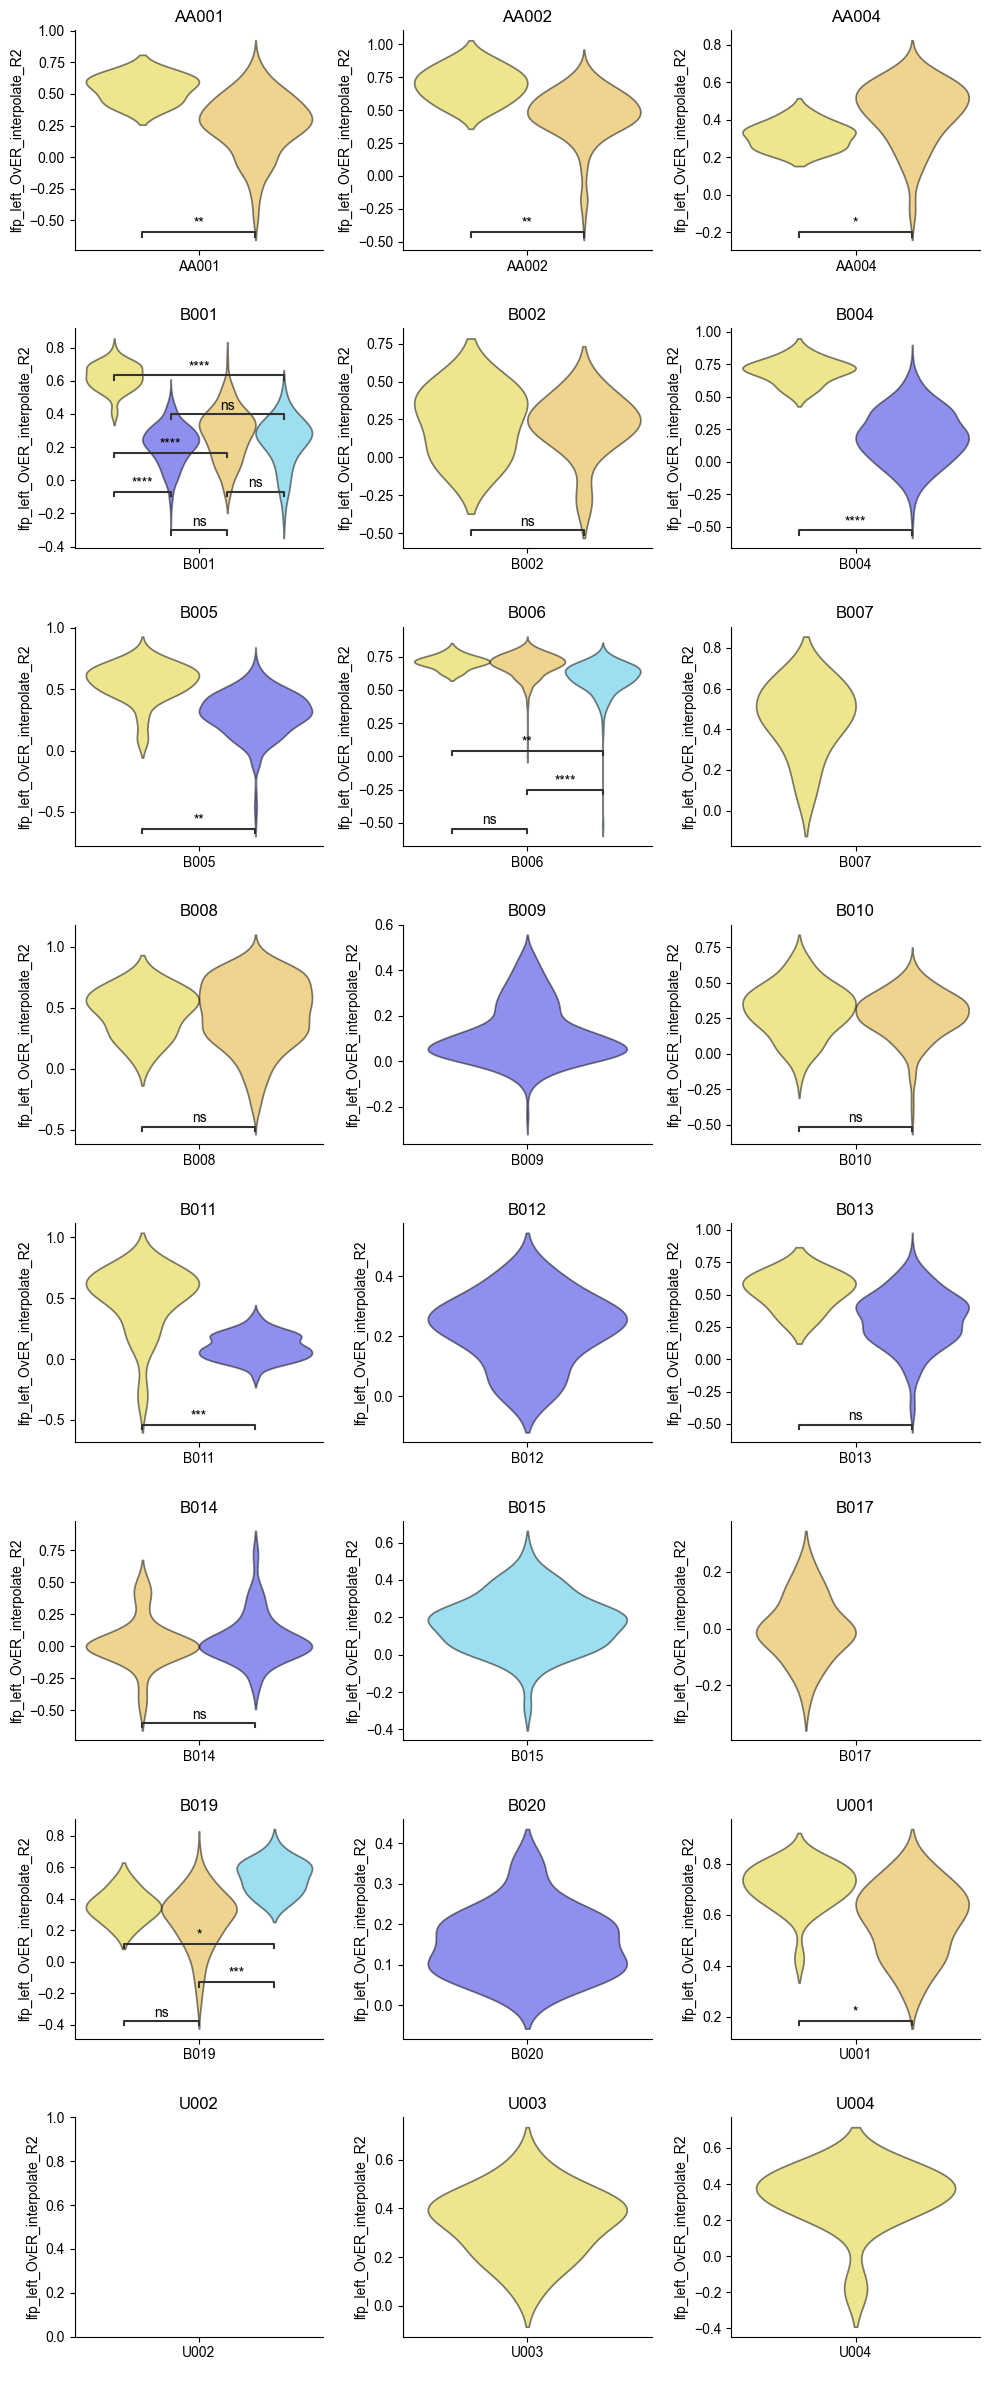

In [26]:
pts = partial_df.pt_id.unique()

fig, axes = plt.subplots(len(pts) // 3, 3, figsize=(10, len(pts) // 3 * 3))
states = ['Pre-DBS', 'Non-Responder', 'Partial Responder', 'Responder']

for pt, ax in zip(pts, axes.flatten()):
    pt_df = partial_df.query('pt_id == @pt and state_label_str in @states').drop_duplicates(subset=['days_since_dbs', 'pt_id'])

    pt_states = pt_df.state_label_str.unique()
    bp = sns.violinplot(pt_df, x = 'pt_id', y='lfp_left_OvER_interpolate_R2', hue='state_label_str', hue_order=pt_states, palette=COL_PAL, ax=ax, legend=False, fill=True, alpha=0.5, common_norm=False, inner=None)

    ax.set_title(pt)
    ax.set_xlabel(' ')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    if len(pt_states) == 1:
        continue

    try:
        def get_values_and_days(df, state):
            sub = df.query('state_label_str == @state').dropna(subset='lfp_left_OvER_interpolate_R2')
            return (
                sub['lfp_left_OvER_interpolate_R2'].values,
                sub['days_since_dbs'].values,
            )

        pairs = list(combinations(pt_states, 2))
        pairs = [((pt, p[0]), (pt, p[1])) for p in pairs]

        pvalues = []
        for (x1, x2) in pairs:
            (pt1, s1), (pt2, s2) = x1, x2
            group1, days1 = get_values_and_days(pt_df, s1)
            group2, days2 = get_values_and_days(pt_df, s2)
            _, p = ttest_ind_with_neff_correction(group1, group2, days1, days2)
            pvalues.append(p)

        annot = Annotator(
            bp, pairs, data=pt_df,
            x='pt_id', y='lfp_left_OvER_interpolate_R2',
            hue='state_label_str', hue_order=list(pt_states),
        )
        annot.configure(
            test=None,                 # tell it not to run an internal test
            text_format='star',
            loc='inside',
            verbose=1,
            comparisons_correction='HB',
            correction_format='replace',
        )
        annot.set_pvalues_and_annotate(pvalues)
    except Exception:
        pass
    
fig.tight_layout()
plt.show()

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Pre-DBS vs. Non-Responder: Welch's t-test independent samples with Holm-Bonferroni correction, P_val:4.293e-05 t=4.127e+00
Non-Responder vs. Partial Responder: Welch's t-test independent samples with Holm-Bonferroni correction, P_val:5.733e-01 t=5.635e-01
Partial Responder vs. Responder: Welch's t-test independent samples with Holm-Bonferroni correction, P_val:1.490e-55 t=1.799e+01
Pre-DBS vs. Partial Responder: Welch's t-test independent samples with Holm-Bonferroni correction, P_val:2.220e-04 t=3.712e+00
Non-Responder vs. Responder: Welch's t-test independent samples with Holm-Bonferroni correction, P_val:1.837e-194 t=3.180e+01
Pre-DBS vs. Responder: Welch's t-test independent samples with Holm-Bonferroni correction, P_val:3.981e-76 t=2.303e+01


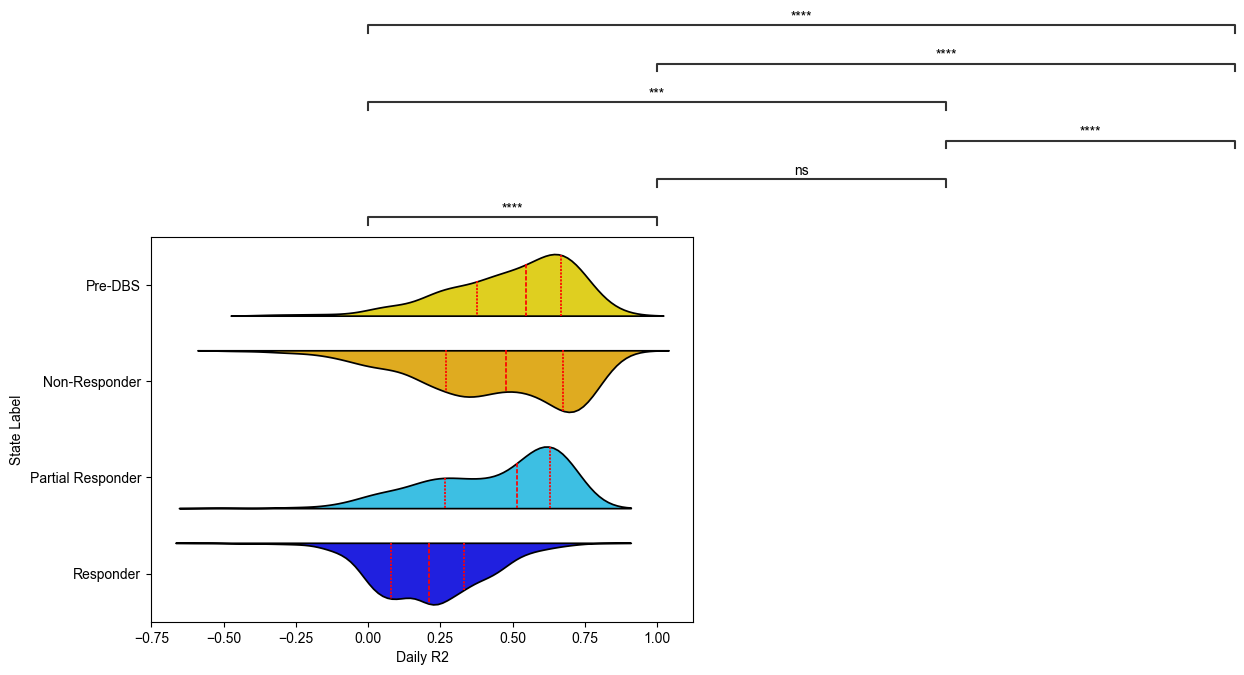

In [30]:
fig, ax = plt.subplots(1, 1, figsize=(7, 5))
states = ['Pre-DBS', 'Non-Responder', 'Partial Responder', 'Responder']

# Grouped clinical state boxplot comparison 
plot_df = partial_df.query('state_label_str in @states and "AA" not in pt_id').drop_duplicates(subset=['days_since_dbs', 'pt_id'])
feature = 'lfp_left_OvER_interpolate_R2'
bp = sns.violinplot(plot_df, x=feature, y='state_label_str', inner='quart', palette=COL_PAL, ax=ax, legend=False, width=0.8, gap=0.2, order=states, split=True, inner_kws=dict(color='red'))

ax.set_xlabel('Daily R2')
ax.set_ylabel('State Label')

pairs = list(combinations(plot_df.state_label_str.unique(), 2))
annot = Annotator(bp, pairs, data=plot_df, x='state_label_str', y=feature, width=1, gap=0.1, order=states)
annot.configure(test='t-test_welch', text_format='star', loc='outside', verbose=2, comparisons_correction='HB', correction_format='replace')
annot.apply_and_annotate()
fig.tight_layout()
plt.show()

## B

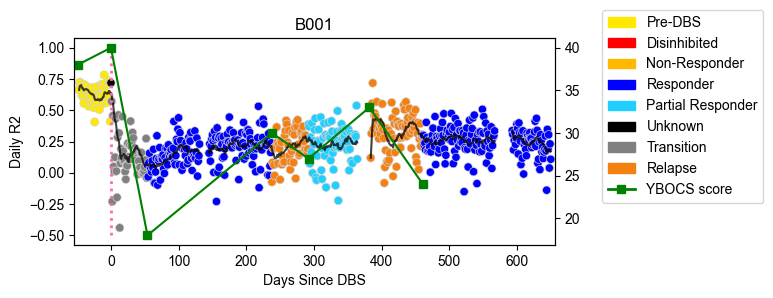

In [36]:
# B001 example relapse

fig, ax = plt.subplots(1, 1, figsize=(6, 3))

pt_df = partial_df.query('pt_id == "B001"').drop_duplicates(subset='days_since_dbs').sort_values('days_since_dbs')
pt_df.loc[pt_df['state_label_str'] == 'Non-Responder', 'state_label_str'] = 'Relapse'

sns.scatterplot(data=pt_df, x='days_since_dbs', y='lfp_left_OvER_interpolate_R2', hue='state_label_str', hue_order=df.state_label_str.unique(), palette=COL_PAL, ec='lightgray', ax=ax, legend=False)
ax.plot(pt_df.days_since_dbs, pt_df.left_R2_rolling_avg_14d, color='black', alpha=0.75)
ax.vlines(0, ymin=-0.5, ymax=1, ls='dotted', colors='hotpink', lw=2)

scale_ax = ax.twinx()
scale_df = pt_df.drop_duplicates(subset='most_recent_YBOCS_value')
scale_ax.plot(scale_df.days_since_dbs, scale_df.most_recent_YBOCS_value, marker='s', color='green')

ax.set_title('B001')
ax.set_ylabel('Daily R2')
ax.set_xlabel('Days Since DBS')
ax.set_xlim(pt_df.days_since_dbs.iloc[0]-5, pt_df.days_since_dbs.iloc[-1]+5)

handles = [mpatches.Patch(color=v, label=k) for k, v in COL_PAL.items()]
yb_line = mlines.Line2D([], [], color='green', linewidth=2, marker='s', label='YBOCS score')

fig.legend(handles=[*handles, yb_line], loc='upper left', bbox_to_anchor=(1, 1))
fig.tight_layout()
plt.show()

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

B001_Partial Responder vs. B001_Responder: Custom statistical test with Holm-Bonferroni correction, P_val:6.441e-01
B001_Pre-DBS vs. B001_Partial Responder: Custom statistical test with Holm-Bonferroni correction, P_val:3.096e-11
B001_Responder vs. B001_Relapse: Custom statistical test with Holm-Bonferroni correction, P_val:1.016e-01
B001_Pre-DBS vs. B001_Responder: Custom statistical test with Holm-Bonferroni correction, P_val:1.417e-14
B001_Partial Responder vs. B001_Relapse: Custom statistical test with Holm-Bonferroni correction, P_val:3.168e-01
B001_Pre-DBS vs. B001_Relapse: Custom statistical test with Holm-Bonferroni correction, P_val:8.615e-10


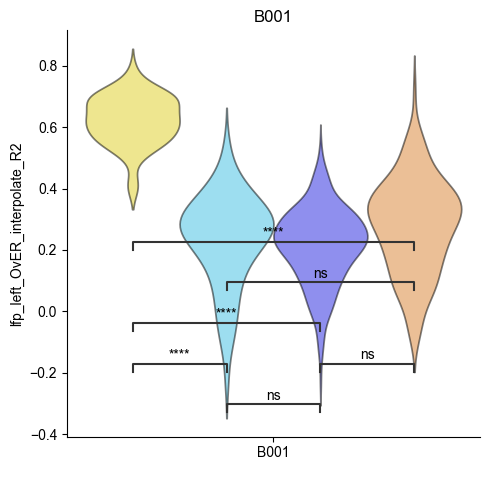

In [49]:
fig, ax = plt.subplots(1, 1, figsize=(5, 5))

pt_states = ['Pre-DBS', 'Partial Responder', 'Responder', 'Relapse']
pt_df.query('state_label_str.isin(@pt_states)', inplace=True)
bp = sns.violinplot(pt_df, x='pt_id', y='lfp_left_OvER_interpolate_R2', hue='state_label_str', hue_order=pt_states, palette=COL_PAL, ax=ax, legend=False, fill=True, alpha=0.5, common_norm=False, inner=None)

ax.set_title('B001')
ax.set_xlabel(' ')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

state_pairs = list(combinations(pt_states, 2))
pairs = [(('B001', p[0]), ('B001', p[1])) for p in state_pairs]

pvalues = []
for (s1, s2) in state_pairs:
    group1, days1 = get_values_and_days(pt_df, s1)
    group2, days2 = get_values_and_days(pt_df, s2)
    _, p = ttest_ind_with_neff_correction(group1, group2, days1, days2)
    pvalues.append(p)

annot = Annotator(
    bp, pairs, data=pt_df,
    x='pt_id', y='lfp_left_OvER_interpolate_R2',
    hue='state_label_str', hue_order=list(pt_states),
)
annot.configure(
    test=None,                 # tell it not to run an internal test
    text_format='star',
    loc='inside',
    verbose=1,
    comparisons_correction='HB',
    correction_format='replace',
)
annot.set_pvalues_and_annotate(pvalues)

fig.tight_layout()
plt.show()

## LinAR-k Model Supp Figure

In [4]:
## LinAR-k model with 3 day sliding window

window_size = 3

ark_df = df.copy()
hem = 'left'

# Generate lag terms
lag_prefix = f"lfp_{hem}_OvER_interpolate_z_scored_lag_"
all_lags = [f"{lag_prefix}{i}" for i in range(1, 145)] # Up to 1 day of lag terms

groups_left = df.groupby(
        ["pt_id", "lead_location", "contig_left"], group_keys=False
)

for k, lag_label in tqdm(enumerate(all_lags), desc=f'Generating Lag terms for {hem} hem'):
    if k == 0:
        continue
    join_df = groups_left.apply(
        lambda g: pd.DataFrame(
            {f"{lag_label}": g['lfp_left_OvER_interpolate_z_scored'].shift(periods=k+1)}
        ),
        include_groups=False,
    )
    
    ark_df = ark_df.join(join_df, how="left")


Generating Lag terms for left hem: 144it [01:36,  1.49it/s]


In [ ]:
pt_groups = ark_df.groupby('pt_id', group_keys=False)

tqdm.pandas(desc=f'Applying autoregressive model for {hem} hem')
hem_results_df = pt_groups.progress_apply(
    lambda g: apply_sliding_window(
        g, all_lags, f'lfp_{hem}_OvER_interpolate_z_scored', window_size=window_size),
    include_groups=False
)
ark_df = df.merge(
    hem_results_df,
    how='left',
    left_index=True,
    right_index=True,
    suffixes=('', '_ark')
)
ark_df.to_parquet('df_w_ark.parq')

Applying autoregressive model for left hem:   4%|▍         | 1/24 [00:00<00:07,  3.17it/s]

Converged after 1 iteration(s): ['lfp_left_OvER_interpolate_z_scored_lag_1']
Converged after 1 iteration(s): ['lfp_left_OvER_interpolate_z_scored_lag_1']
Converged after 1 iteration(s): ['lfp_left_OvER_interpolate_z_scored_lag_1']
Converged after 1 iteration(s): ['lfp_left_OvER_interpolate_z_scored_lag_1']
Converged after 1 iteration(s): ['lfp_left_OvER_interpolate_z_scored_lag_1']
Iteration 0: no lags survived k-fold screening.
Converged after 1 iteration(s): ['lfp_left_OvER_interpolate_z_scored_lag_1']
Converged after 1 iteration(s): ['lfp_left_OvER_interpolate_z_scored_lag_1']
Converged after 1 iteration(s): ['lfp_left_OvER_interpolate_z_scored_lag_16']
Converged after 1 iteration(s): ['lfp_left_OvER_interpolate_z_scored_lag_1', 'lfp_left_OvER_interpolate_z_scored_lag_16']
Iteration 0: dropping ['lfp_left_OvER_interpolate_z_scored_lag_20'] (non-significant on full data)
Converged after 2 iteration(s): ['lfp_left_OvER_interpolate_z_scored_lag_1']
Iteration 0: dropping ['lfp_left_OvER

Applying autoregressive model for left hem:   8%|▊         | 2/24 [00:17<03:47, 10.36s/it]

Converged after 1 iteration(s): ['lfp_left_OvER_interpolate_z_scored_lag_1']
Converged after 1 iteration(s): ['lfp_left_OvER_interpolate_z_scored_lag_1']
Converged after 1 iteration(s): ['lfp_left_OvER_interpolate_z_scored_lag_1']
Converged after 1 iteration(s): ['lfp_left_OvER_interpolate_z_scored_lag_1']
Converged after 1 iteration(s): ['lfp_left_OvER_interpolate_z_scored_lag_1']
Converged after 1 iteration(s): ['lfp_left_OvER_interpolate_z_scored_lag_1']
Iteration 0: dropping ['lfp_left_OvER_interpolate_z_scored_lag_31', 'lfp_left_OvER_interpolate_z_scored_lag_32', 'lfp_left_OvER_interpolate_z_scored_lag_80'] (non-significant on full data)
Converged after 2 iteration(s): ['lfp_left_OvER_interpolate_z_scored_lag_1']
Converged after 1 iteration(s): ['lfp_left_OvER_interpolate_z_scored_lag_1']
Iteration 0: dropping ['lfp_left_OvER_interpolate_z_scored_lag_54'] (non-significant on full data)
Converged after 2 iteration(s): ['lfp_left_OvER_interpolate_z_scored_lag_1']
Converged after 1 i

Applying autoregressive model for left hem:  12%|█▎        | 3/24 [00:35<04:44, 13.57s/it]

...

Applying autoregressive model for left hem: 100%|██████████| 24/24 [12:06<00:00,  9.86s/it]

Converged after 1 iteration(s): ['lfp_left_OvER_interpolate_z_scored_lag_1']
Iteration 0: no lags survived k-fold screening.
Converged after 1 iteration(s): ['lfp_left_OvER_interpolate_z_scored_lag_1']
Iteration 0: no lags survived k-fold screening.
Converged after 1 iteration(s): ['lfp_left_OvER_interpolate_z_scored_lag_1']
Converged after 1 iteration(s): ['lfp_left_OvER_interpolate_z_scored_lag_1']
Converged after 1 iteration(s): ['lfp_left_OvER_interpolate_z_scored_lag_1']
Iteration 0: dropping ['lfp_left_OvER_interpolate_z_scored_lag_62'] (non-significant on full data)
Converged after 2 iteration(s): ['lfp_left_OvER_interpolate_z_scored_lag_1']
Converged after 1 iteration(s): ['lfp_left_OvER_interpolate_z_scored_lag_1']
Iteration 0: no lags survived k-fold screening.
Iteration 0: dropping ['lfp_left_OvER_interpolate_z_scored_lag_87'] (non-significant on full data)
Converged after 2 iteration(s): ['lfp_left_OvER_interpolate_z_scored_lag_1', 'lfp_left_OvER_interpolate_z_scored_lag_83

Applying autoregressive model for left hem: 100%|██████████| 24/24 [12:08<00:00, 30.36s/it]

Converged after 1 iteration(s): ['lfp_left_OvER_interpolate_z_scored_lag_1']


" ark_df = df.merge(\n    hem_results_df,\n    how='left',\n    left_index=True,\n    right_index=True\n) "

In [15]:
ark_df = pd.read_parquet('df_w_ark.parq')
ark_df.head(5)

,pt_id,time_bin_time,days_since_dbs,lfp_left_raw,stim_left,lfp_right_raw,stim_right,lead_location,left_lead_model,right_lead_model,...,lfp_left_OvER_interpolate_z_scored_lag_139,lfp_left_OvER_interpolate_z_scored_lag_140,lfp_left_OvER_interpolate_z_scored_lag_141,lfp_left_OvER_interpolate_z_scored_lag_142,lfp_left_OvER_interpolate_z_scored_lag_143,lfp_left_OvER_interpolate_z_scored_lag_144,lfp_left_OvER_interpolate_phi_1_ark,lfp_left_OvER_interpolate_preds_ark,lfp_left_OvER_interpolate_residuals_ark,lfp_left_OvER_interpolate_R2_ark
0,AA001,00:00:00,-8,253.0,0.0,366.0,0.0,VC/VS,LEAD_B33015,LEAD_B33015,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,AA001,00:10:00,-8,181.0,0.0,312.0,0.0,VC/VS,LEAD_B33015,LEAD_B33015,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,AA001,00:20:00,-8,198.0,0.0,306.0,0.0,VC/VS,LEAD_B33015,LEAD_B33015,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,AA001,00:30:00,-8,185.0,0.0,269.0,0.0,VC/VS,LEAD_B33015,LEAD_B33015,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,AA001,00:40:00,-8,215.0,0.0,314.0,0.0,VC/VS,LEAD_B33015,LEAD_B33015,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## A

In [ ]:
# Daily R2

